# Example: Singular Value Decomposition (SVD) of the Daily Growth Rate of the S&P500.
In this example, we decompose the daily growth rate values for components of the S&P500 using SVD.
Singular value decomposition helps us break down complex data into simpler, interpretable components.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * **Apply SVD to Financial Data:** Calculate growth rates from S&P500 stock prices and break down the data matrix using SVD. You'll learn how to use linear algebra to find patterns in financial data.
> * **Understand What the Math Tells Us:** Figure out what the singular values mean and how much of the market behavior each part explains. You'll see the difference between market-wide movements and individual stock changes.
> * **Visualize Market Patterns:** Create pictures of market behavior using the SVD components and spot trends in the data. This helps you see how different stocks move together and identify important time periods in the market.


By applying SVD to the daily growth rates of S&P500 stocks, we can uncover underlying patterns and trends in the market. Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time. 

Let's load the `original_dataset::DataFrame` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  "NWSA" => 2767×8 DataFrame…
  "BBWI" => 859×8 DataFrame…
  "CAG"  => 2767×8 DataFrame…
  "GPC"  => 2767×8 DataFrame…
  "FCX"  => 2767×8 DataFrame…
  "GILD" => 2767×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

How many firms do we have the full number of trading days? Let's use [the `length(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.length) - notice this works for dictionaries, in addition to arrays, sets and other collections.

In [5]:
length(dataset) # tells us how many keys are in the dictionary (how many firms in our dataset?)

424

Finally, let's get a list of the firms in our cleaned up dataset (and sort them alphabetically). We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

___

## Task 1: Compute the growth rate matrix
In this task, we'll compute the growth-rate matrix $\mathbf{G}\in\mathbb{R}^{(T-1)\times{N}}$ from the daily closing prices, with one row per trading day and one column per firm. The decomposition in the next task takes this matrix as its input.

>  __Continuously Compounded Growth Rate (CCGR)__
>
> Let's assume a model of the share price of firm $i$ is governed by an expression of the form:
>$$
\begin{align*}
S^{(i)}_{j} &= S^{(i)}_{j-1}\;\exp\left(g^{(i)}_{j,j-1}\Delta{t}_{j}\right)
\end{align*}
$$
> where $S^{(i)}_{j-1}$ denotes the share price of firm $i$ at time index $j-1$, $S^{(i)}_{j}$ denotes the share price of firm $i$ at time index $j$, and $\Delta{t}_{j} = t_{j} - t_{j-1}$ denotes the length of a time step (units: years) between time index $j-1$ and $j$. The value we are going to estimate is the growth rate $g^{(i)}_{j,j-1}$ (units: inverse years) for each firm $i$, and each time step in the dataset.

We've implemented [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) which takes the cleaned up dataset, and a list of ticker symbols, and returns the growth rate array computed from daily closing prices. Each row of the growth rate array is a time step, while each column corresponds to a firm from the `list_of_tickers::Array{String,1}` array. We store the result in the `growth_rate_array::Array{Float64,2}` variable:

In [8]:
growth_rate_array = let

    # initialize -
    τ = (1/252); # time-step one-day in units of years (trading year is 252 days)
    r̄ = 0.0; # assume the risk-free rate is 0

    # compute the growth matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = τ, 
        risk_free_rate = r̄, keycol = :close); # use daily closing prices

    growth_rate_array; # return
end

2766×424 Matrix{Float64}:
 -1.24278     4.61017   -2.42266   …  -0.84801     -1.77853   -0.550992
  3.57829    -1.16807    3.09151       2.58223      0.763766   0.943821
  4.08994     6.70068   -1.96701      -0.186909     2.19352   -2.84214
  0.0862643  15.8187     2.78949       1.16591      1.84126    1.74067
  2.23376    -0.600307   4.59614       0.557728    -1.33776    4.53222
  0.0        -6.08305   -2.9592    …  -2.89497     -3.46078   -5.9555
  4.0298      1.92769    7.19459       4.37624      0.169926   0.554456
  1.92882    -0.262     -0.278726      0.0922908    4.29484   -0.316682
  0.667042    4.33149    0.878012     -1.99174     -3.02404    1.50071
  0.873112    5.77384    1.19432      -1.49251      2.85698   -2.13527
  0.580784    5.31595   -0.937913  …   0.140299    10.7146    -3.68007
  0.330946    4.39972   -0.534465      0.840156     2.47022    1.52655
 -6.11223     1.20864   -3.05745      -2.19966     -4.96489    2.23293
  ⋮                                ⋱            

> **Growth Rate Matrix Structure**
>
> The `growth_rate_array` is a matrix $\mathbf{G} \in \mathbb{R}^{m \times n}$ where each **row** represents a trading day (time step) in our dataset, each **column** represents a firm from the S&P500, and each **element** $G_{i,j}$ contains the continuously compounded growth rate for firm $j$ on day $i$.

The matrix has 424 firms (columns) and there are $T-1$ = 2,766 trading days (rows), capturing the daily growth rate dynamics of the S&P500 components from 2014 to 2024. Is there redundancy in the data?

Let's check the rank of the growth rate array using [the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank):

In [9]:
rank(growth_rate_array)

424

The growth rate matrix has **full column rank** (rank = 424), which means that all 424 firms contribute independent information to the dataset. 

> __Why is this significant?__ This tells us that no firm's growth pattern can be perfectly predicted from the others. Each stock brings unique behavior to the market, even though there may be strong correlations between them.

Let's dig deeper into the market behavior using SVD!
___

## Task 2: Let's decompose the growth matrix using SVD
In this task, we'll decompose the growth-rate matrix using the singular value decomposition (SVD). The decomposition rewrites the matrix as a sum of simple patterns, ordered by how much of the market's movement each one accounts for.

Let the growth rate matrix be denoted by $\mathbf{G} \in \mathbb{R}^{m\times n}$, where $m$ is the number of time steps (days) in our dataset, and $n$ is the number of firms in our dataset. The SVD of $\mathbf{G}$ is given by:
$$
\begin{align*}
\mathbf{G} &= \mathbf{U}\mathbf{\Sigma}\mathbf{V}^{\top}
\end{align*}
$$
where $\mathbf{U} \in \mathbb{R}^{m\times m}$ is a matrix whose columns are the left singular vectors of $\mathbf{G}$, $\mathbf{\Sigma} \in \mathbb{R}^{m\times n}$ is a diagonal matrix whose diagonal entries are the singular values of $\mathbf{G}$, and $\mathbf{V} \in \mathbb{R}^{n\times n}$ is a matrix whose columns are the right singular vectors of $\mathbf{G}$.

> __Why SVD?__
>
> SVD is a powerful tool for analyzing the structure of data. It can be used for dimensionality reduction, noise reduction, and feature extraction. In the context of financial data, SVD can help us identify underlying patterns and trends in the growth rates of different firms.

So what exactly does the decomposition compute?

> __What is SVD?__
>
> Singular value decomposition (SVD) can be thought of as decomposing a matrix into a weighted, ordered sum of separable matrices, e.g., frames of market behavior. Let $\mathbf{G}\in\mathbb{R}^{m\times{n}}$ have the singular value decomposition $\mathbf{G} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^{T}$. Then, the matrix $\mathbf{G}\in\mathbb{R}^{m\times{n}}$ can be written as:
> $$
\begin{align*}
\mathbf{G} &= \sum_{i=1}^{r_{\mathbf{G}}}\sigma_{i}\;\underbrace{\left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)}_{\mathbf{G}_{i}}
\end{align*}    
$$
> where $r_{\mathbf{G}}$ is the __rank__ of matrix $\mathbf{G}$, the vectors $\mathbf{u}_{i}$ and $\mathbf{v}_{i}$ are the ith left and right singular vectors, and $\sigma_{i}$ are the ordered singular values. The [outer product](https://en.wikipedia.org/wiki/Outer_product) $\mathbf{G}_{i} = \left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)$ is the separable component of the matrix $\mathbf{G}$ that has rank one. Thus, we are rebuilding the matrix $\mathbf{G}$ as a weighted sum of rank one matrices. The weights are the singular values $\sigma_{i}$. The singular values are ordered from largest to smallest, so the first few terms in the sum capture the most important features of the matrix $\mathbf{G}$. 

This is the basis for data reduction using SVD. By truncating the sum after a few terms, we can obtain a low-rank approximation of the matrix $\mathbf{G}$ that captures the most important features of the data.

We'll use the [`svd(...)` function exported from the `LinearAlgebra.jl` package](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) to compute the singular value decomposition of `growth_rate_array::Array{Float64,2}`. 

Because our matrix is tall ($m>n$), Julia returns the thin factorization: `U` is an $m\times n$ matrix holding the left singular vectors, `S` is a vector holding the $n$ singular values, and `V` is an $n\times n$ matrix holding the right singular vectors.

In [10]:
U,S,V = svd(growth_rate_array);

One of the cool things about [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) is that modes (the rank one components) are sorted and weighted by the singular values. Thus, we can compute the contribution of each mode by looking at the singular values.

Let's compute and visualize how much of the matrix's total squared variation (its squared Frobenius norm) the leading modes capture by looking at the cumulative sum.

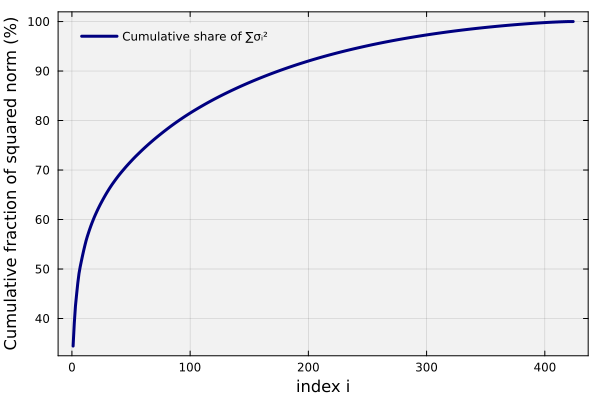

In [11]:
let
    
    # make a plot of the fractional contribution of the singular values
    number_of_modes = length(S);
    SS = S.^2/sum(S.^2); # fraction of the squared Frobenius norm
    explained_array = [100*sum(SS[1:i]) for i ∈ 1:number_of_modes]; # comprehension

    plot(explained_array, label="Cumulative share of ∑σᵢ²", lw=3, c=:navy)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    xlabel!("index i", fontsize=18)
    ylabel!("Cumulative fraction of squared norm (%)", fontsize=18)
end

### What do the singular values tell us about the market behavior?

The plot above shows how the cumulative fraction of squared variation grows as we add modes. The shape of that curve tells us how concentrated the market's movement is.

> **Key Insight**: The first mode alone carries roughly a third of the total squared variation, and about 7 modes (fewer than 2% of them) reach 50%. That points to a single market-wide factor moving the component stocks together. The rest has a long tail: roughly 175 modes are needed to reach 90%. That tail is what we would expect from industry groups, individual company performance, and one-off events layered on top of the shared market move.

Next, let's visualize the first few modes to see what they tell us about market behavior.
___

## Task 3: Visualize the contribution of each mode
In this task, we'll rebuild the growth-rate matrix from its leading modes and view the result as a grayscale image, then compare it against the same picture drawn from all of the data.

In the visualization below, we'll reconstruct and display the market behavior using up to a specified number of modes. This shows how we can build up approximations of the original data matrix using progressively more components.

> **Visualization Approach**: We're creating grayscale images from the SVD components where each rank-1 matrix $\mathbf{G}_i = \sigma_i \mathbf{u}_i \mathbf{v}_i^T$ represents one "mode" of market behavior. By converting the numerical growth rate values to color intensities (dark = negative, gray = moderate positive, light = large positive), we can visually see patterns in both time (horizontal direction) and across different stocks (vertical direction).

We store the individual market modes as grayscale frames in the `image_frames_dictionary::Dict{Int64, Matrix{Gray{Float64}}}` dictionary variable, where the key is the mode index, and the values are the corresponding weighted rank-one mode matrices.

In [12]:
image_frames_dictionary = let

    # initialize -
    image_frames_dictionary = Dict{Int64,Matrix{Gray{Float64}}}();

    R = rank(growth_rate_array); # how many frames will we have?
    foreach(i -> image_frames_dictionary[i] = S[i]*⊗(U[:,i],V[:,i]), 1:R); # another iteration pattern???

    image_frames_dictionary; # return
end;

`Unhide` the code cell below to see how we computed and then visualized the cumulative contribution of each market mode. We've visualized the transpose of the growth rate matrix, so that time is on the horizontal axis, and firms are on the vertical axis.
> __Colors__: Dark values (black) indicate negative growth rates, gray values indicate moderate positive growth rates (between 0% and 5%), and light values (white) indicate large positive growth rates (greater than 5% per year).

So, do we see any interesting patterns in the modes of market behavior?

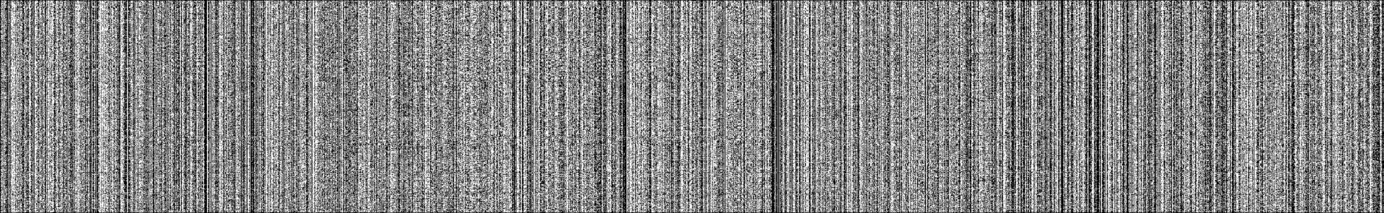

In [13]:
let 
    
    (number_of_trading_days, number_of_firms) = size(growth_rate_array);
    B = zeros(number_of_trading_days, number_of_firms); # initialize

    M = image_frames_dictionary[1];
    number_of_frames = 100;
    for i ∈ 2:number_of_frames
        M += image_frames_dictionary[i]
    end

    for i ∈ 1:number_of_trading_days
        for j ∈ 1:number_of_firms
            if (M[i,j] < 0.0)
                B[i,j] = 0.0; # dark
            elseif (0.0 <= M[i,j] < 0.05)
                B[i,j] = 0.5; # gray
            else
                B[i,j] = 1.0; # light
            end
        end
    end

    Gray.(transpose(B)) # rows are firms; columns are trading days
end

`Unhide` the code cell below to see how we visualized the entire market behavior using all modes.
> __Colors__: Dark values (black) indicate negative growth rates, gray values indicate moderate positive growth rates (between 0% and 5%), and light values (white) indicate large positive growth rates (greater than 5% per year).

How does the entire market behavior look when we use all modes?

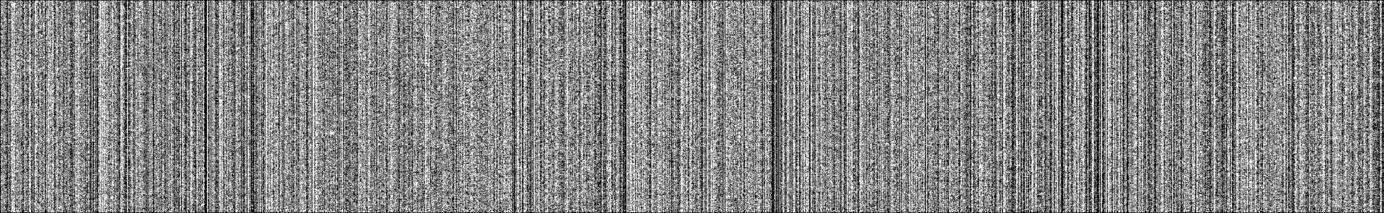

In [14]:
let

    # initialize -
    (number_of_trading_days, number_of_firms) = size(growth_rate_array);
    B = zeros(number_of_trading_days, number_of_firms); # initialize

    for i ∈ 1:number_of_trading_days
        for j ∈ 1:number_of_firms
            if (growth_rate_array[i,j] < 0.0)
                B[i,j] = 0.0; # dark
            elseif (0.0 < growth_rate_array[i,j] < 0.05)
                B[i,j] = 0.5; # gray
            else
                B[i,j] = 1.0; # light
            end
        end
    end

    Gray.(transpose(B)) # rows are firms; columns are trading days
end

### What patterns do we see in the market behavior?

Looking at the grayscale visualizations, we can observe several clear patterns in how the growth rates are distributed across time and firms.

> **Observable Patterns**: The visualizations show distinct vertical bands (time periods where most stocks moved in the same direction) and horizontal bands (groups of stocks that tend to move together). Dark vertical stripes indicate days when many firms experienced negative growth simultaneously, while light areas show periods of broad positive growth. The horizontal patterns suggest that certain groups of firms have correlated behavior.

These visual patterns demonstrate that the SVD decomposition is successfully identifying structure in what might otherwise appear to be random market data. Pretty cool, right?
___

## Summary

This example applied singular value decomposition to a matrix of daily S&P 500 component growth rates and used low-rank reconstructions to expose shared market structure.

> __Key Takeaways:__
>
> * __The growth-rate matrix organizes two dimensions of variation:__ Rows represent trading-day intervals and columns represent firms, so the matrix records both temporal and cross-sectional behavior.
> * __SVD orders orthogonal modes by importance:__ Each singular value weights a rank-one mode formed from a matched pair of left and right singular vectors, and larger singular values identify modes that account for more squared matrix variation.
> * __Cumulative reconstructions reveal common structure:__ Leading modes reproduce broad market-wide and group-level patterns, while later modes add increasingly asset-specific detail.

The decomposition shows that daily equity growth rates are not merely isolated firm-level observations: a comparatively small set of shared modes can organize a meaningful portion of their joint behavior.

___